#Возьмите полученную в 1-й лабораторной работе картинку ипереведитееёв grayscale-режим (Y = 0.2126⋅ R + 0.7152⋅ G+ 0.0722⋅B), далее используйте это преобразованное изображение вместестремяполутоновыми картинками с образовательного портала.

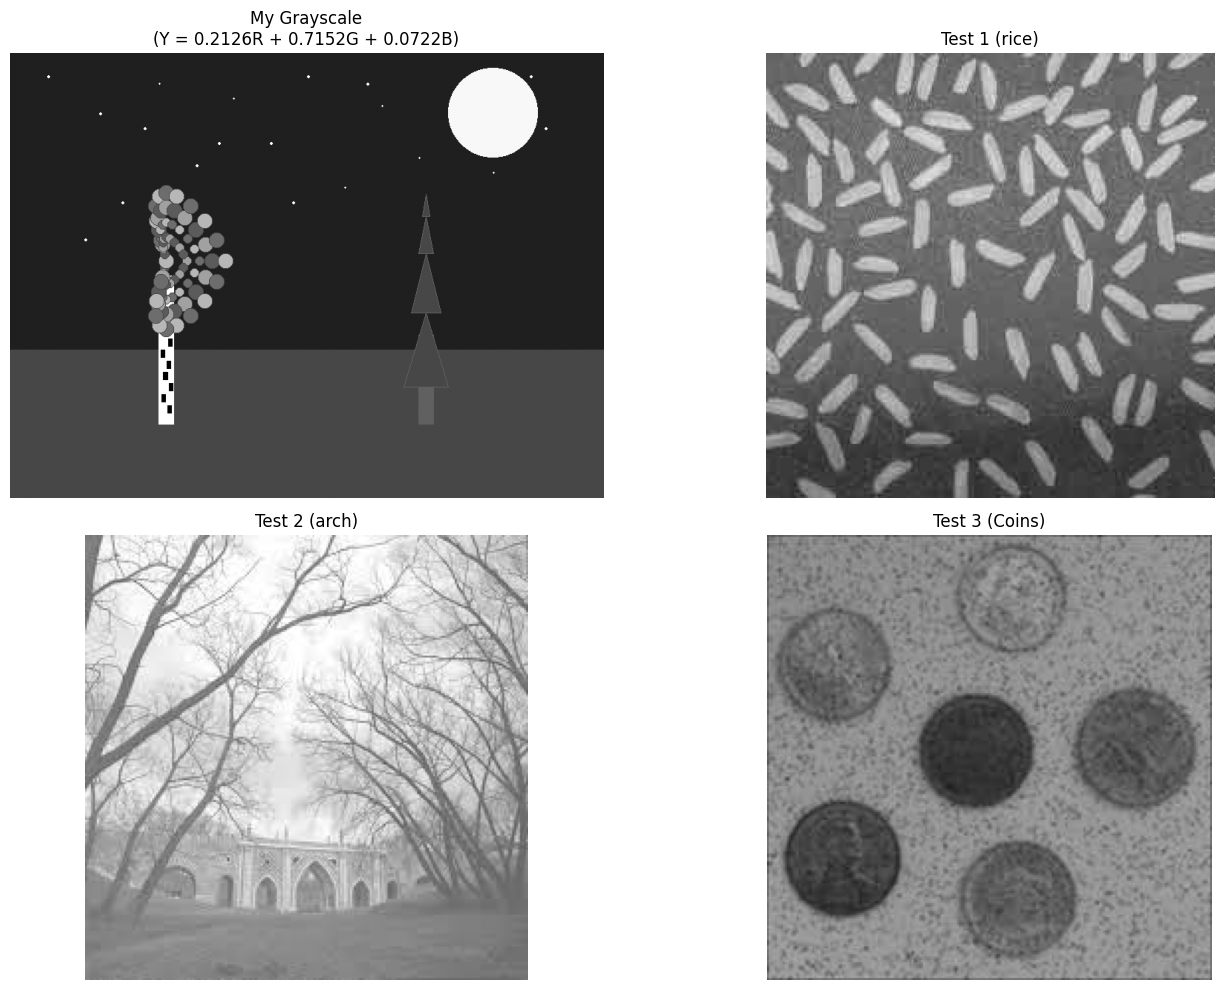

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import cv2
from PIL import Image

%matplotlib inline


img_color = io.imread('summer_night_forest.png')

img_normalized = img_color / 255.0

#Применяем формулу Y = 0.2126*R + 0.7152*G + 0.0722*B
r = img_normalized[:, :, 0]
g = img_normalized[:, :, 1]
b = img_normalized[:, :, 2]
img_gray = 0.2126 * r + 0.7152 * g + 0.0722 * b

img_test1 = io.imread('rice.jpg')
img_test2 = io.imread('arch.jpg')
img_test3 = io.imread('Coins.jpg')

img_test1 = img_test1 / 255.0
img_test2 = img_test2 / 255.0
img_test3 = img_test3 / 255.0

images = [img_gray, img_test1, img_test2, img_test3]
image_names = ['My Grayscale\n(Y = 0.2126R + 0.7152G + 0.0722B)', 'Test 1 (rice)', 'Test 2 (arch)', 'Test 3 (Coins)']

plt.figure(figsize=(15, 10))

for i, (img, name) in enumerate(zip(images, image_names)):
    plt.subplot(2, 2, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(name)
    plt.axis('off')

plt.tight_layout()
plt.show()

#2. Постройте гистограммы изображений

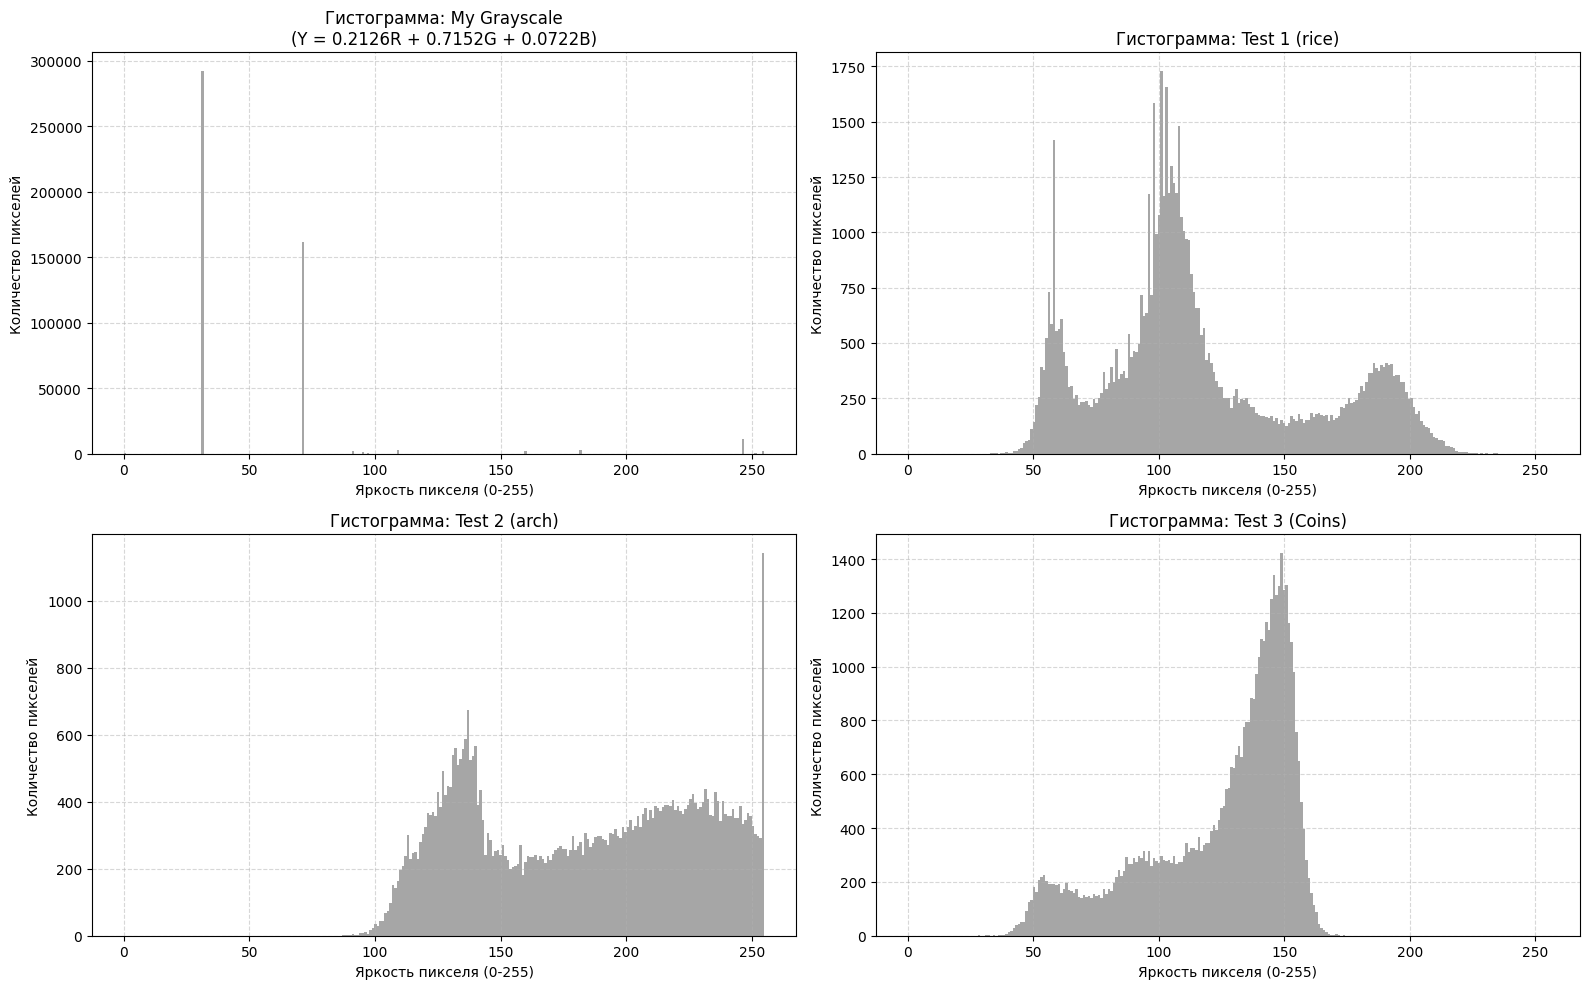

In [50]:
plt.figure(figsize=(16, 10))
for i, (img, name) in enumerate(zip(images, image_names)):
    img_gray = img
    if len(img.shape) == 3:
        if img.max() <= 1.0:
            img_gray = (img * 255).astype(np.uint8)
        else:
            img_gray = img.astype(np.uint8)
        img_gray = cv2.cvtColor(img_gray, cv2.COLOR_RGB2GRAY)
    else:
        if img.max() <= 1.0:
            img_gray = (img * 255).astype(np.uint8)
        else:
            img_gray = img.astype(np.uint8)

    plt.subplot(2, 2, i+1)
    plt.hist(np.ravel(img_gray), bins=256, range=(0, 255), color='gray', alpha=0.7)
    plt.title(f'Гистограмма: {name}')
    plt.xlabel('Яркость пикселя (0-255)')
    plt.ylabel('Количество пикселей')
    plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#Что можно сказать про изображения на основе анализа гистограмм?

My Grayscale
Характеристика: Гистограмма имеет два выраженных пика.

Вывод: Изображение высококонтрастное, с четким разделением на темные и светлые объекты. Хороший динамический диапазон.

Test 1 (rice)
Гистограмма начинается от 0.2 и тянется до 0.9. Огромный пик в районе 0.2 и 0.4.
Вывод:
Изображение преимущественно темное, но не черное. Большая часть пикселей сосредоточена в тенях, однако есть градации до средних тонов.

Test 2 (arch)
Характеристика: Гистограмма смещена вправо (к 1), основной пик в области светлых тонов (0.9)

Вывод: Изображение переэкспонированное (светлое/пересвеченное). Большинство пикселей находятся в светлой области, детали в светах могут быть потеряны.

Test 3 (Coins)
Характеристика: Гистограмма имеет мультимодальный характер с несколькими локальными максимумами в диапазоне 0.2-0.7

Вывод: Изображение содержит несколько различных объектов/областей с разной яркостью. Это идеальный кандидат для пороговой сегментации, так как по впадинам между пиками можно выбрать пороги для выделения отдельных объектов.

#3. Подберите и выполните логарифмические преобразования изображений с помощью попиксельной обработки, постройте гистограммы полученных изображений.

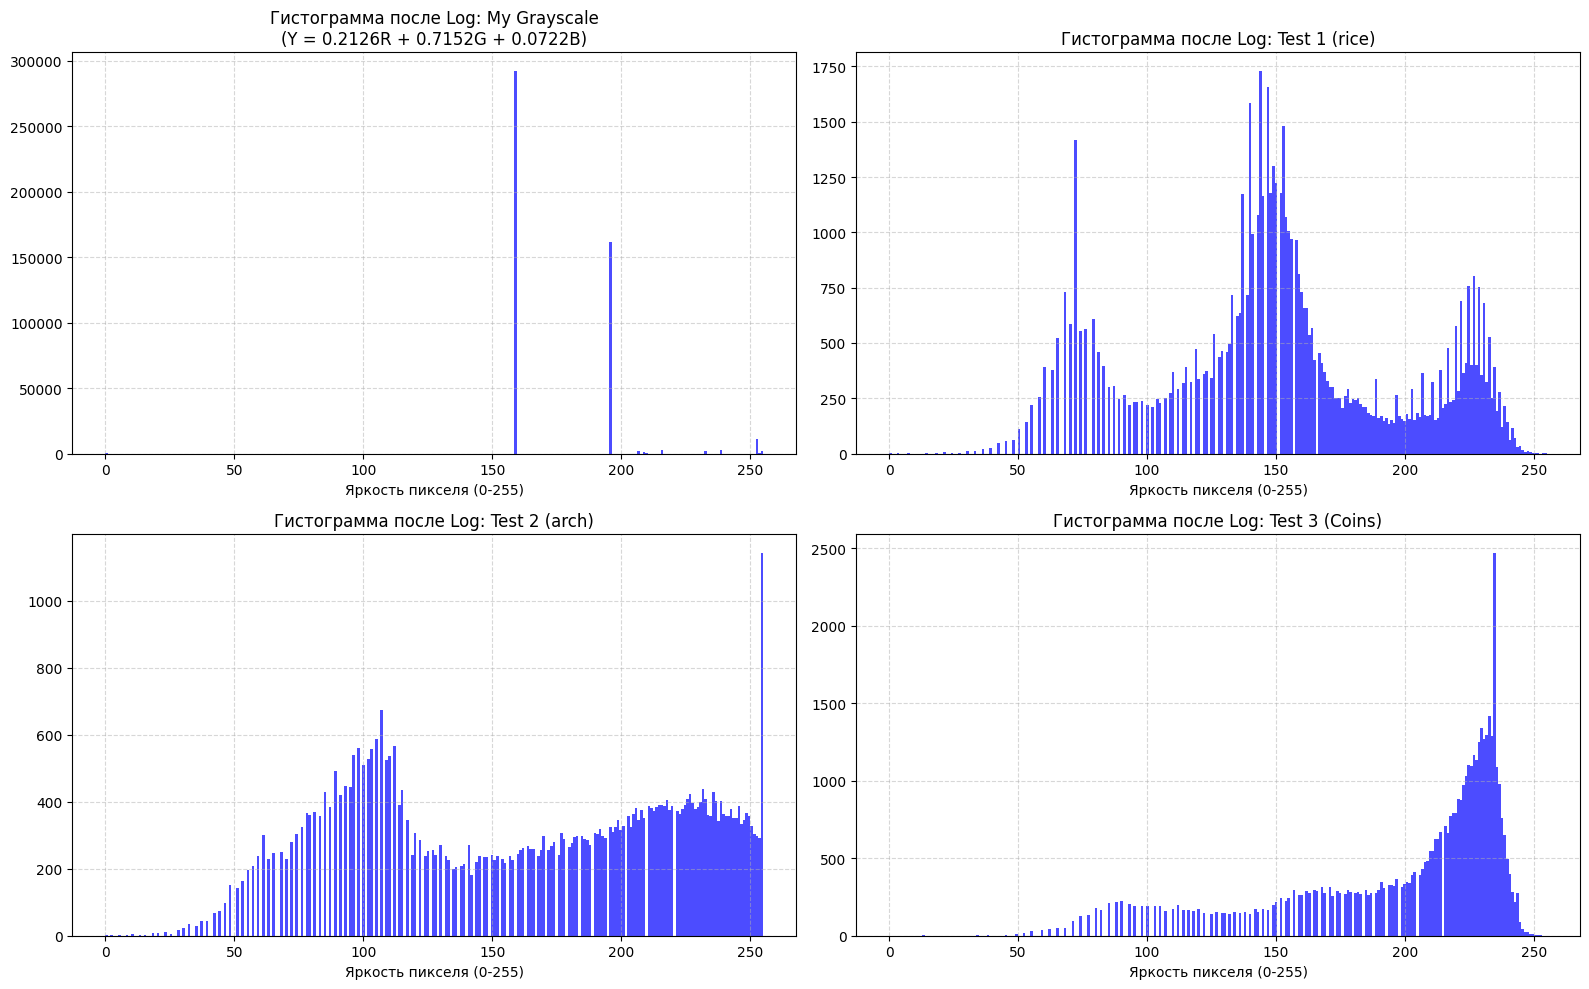

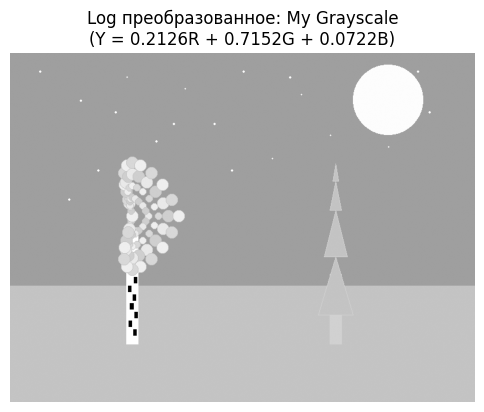

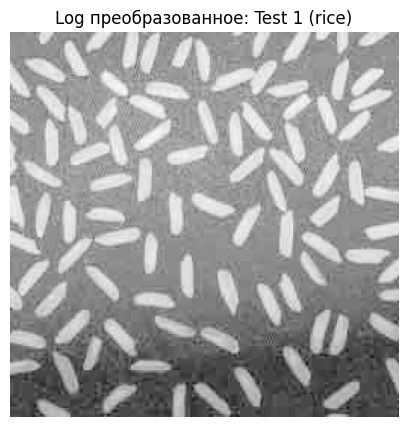

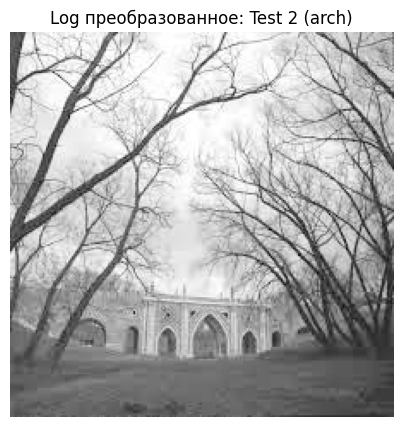

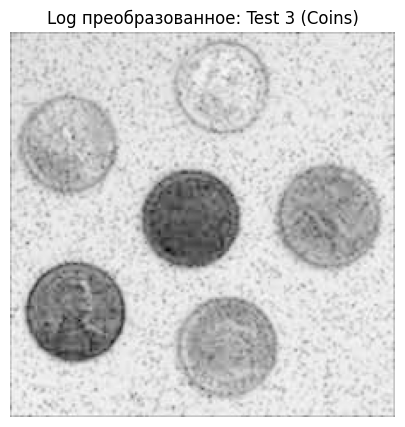

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def log_transform(image, c=1.0):
    # Конвертируем в float для вычислений
    img_float = image.astype(np.float64)
    # Логарифмическое преобразование
    img_log = c * np.log(1 + img_float)
    # Нормализуем в диапазон 0-1
    img_log = (img_log - img_log.min()) / (img_log.max() - img_log.min())
    # Переводим в 0-255
    img_log_255 = (img_log * 255).astype(np.uint8)
    return img_log_255

# Гистограммы после преобразования (значения 0-255)
plt.figure(figsize=(16, 10))
for i, (img, name) in enumerate(zip(images, image_names)):
    # Конвертируем в grayscale если нужно
    img_gray = img
    if len(img.shape) == 3:
        if img.max() <= 1.0:
            img_gray = (img * 255).astype(np.uint8)
        else:
            img_gray = img.astype(np.uint8)
        img_gray = cv2.cvtColor(img_gray, cv2.COLOR_RGB2GRAY)
    else:
        if img.max() <= 1.0:
            img_gray = (img * 255).astype(np.uint8)
        else:
            img_gray = img.astype(np.uint8)

    img_log = log_transform(img_gray)

    # Показываем гистограмму результата
    plt.subplot(2, 2, i+1)
    plt.hist(np.ravel(img_log), bins=256, range=(0, 255), color='blue', alpha=0.7)
    plt.title(f'Гистограмма после Log: {name}')
    plt.xlabel('Яркость пикселя (0-255)')
    plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Преобразованные изображения
for i, (img, name) in enumerate(zip(images, image_names)):
    # Конвертируем в grayscale если нужно
    img_gray = img
    if len(img.shape) == 3:
        if img.max() <= 1.0:
            img_gray = (img * 255).astype(np.uint8)
        else:
            img_gray = img.astype(np.uint8)
        img_gray = cv2.cvtColor(img_gray, cv2.COLOR_RGB2GRAY)
    else:
        if img.max() <= 1.0:
            img_gray = (img * 255).astype(np.uint8)
        else:
            img_gray = img.astype(np.uint8)

    img_log = log_transform(img_gray)

    plt.figure(figsize=(6, 5))
    plt.imshow(img_log, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Log преобразованное: {name}')
    plt.axis('off')
    plt.show()

#Что можно сказать про результаты преобразований? Что дает анализ гистограмм?
My Grayscale
Было два пика (темный и светлый) - стало более равномерное распределение. Детали в средних тонах проявились, но контраст между темным и светлым уменьшился.

Test 1 (темное)
Гистограмма была прижата влево (все темное) - после преобразования растянулась вправо. Результат: стало видно детали в тенях, фото выглядит лучше. Для темных снимков логарифм - самое то.

Test 2 (светлое)
И так все было в правой части - после преобразования еще сильнее уехало вправо. Стало еще более выцветшим, детали потерялись. Для светлых фото логарифм только вредит.

Test 3 (монеты)
Пики сгладились, распределение стало ровнее. Контраст между монетами и фоном снизился, но общая картинка выровнялась.

Что дает анализ гистограмм?


1 Видно, помогло преобразование или нет

2 Понимаем, что происходит с изображением

3 Можно предсказать результат

#4. Подберите степенные преобразования и выполните гамма-коррекцию изображений, постройте гистограммы полученных изображений. Что можно сказать про результаты преобразований? Что дает анализ гистограмм?

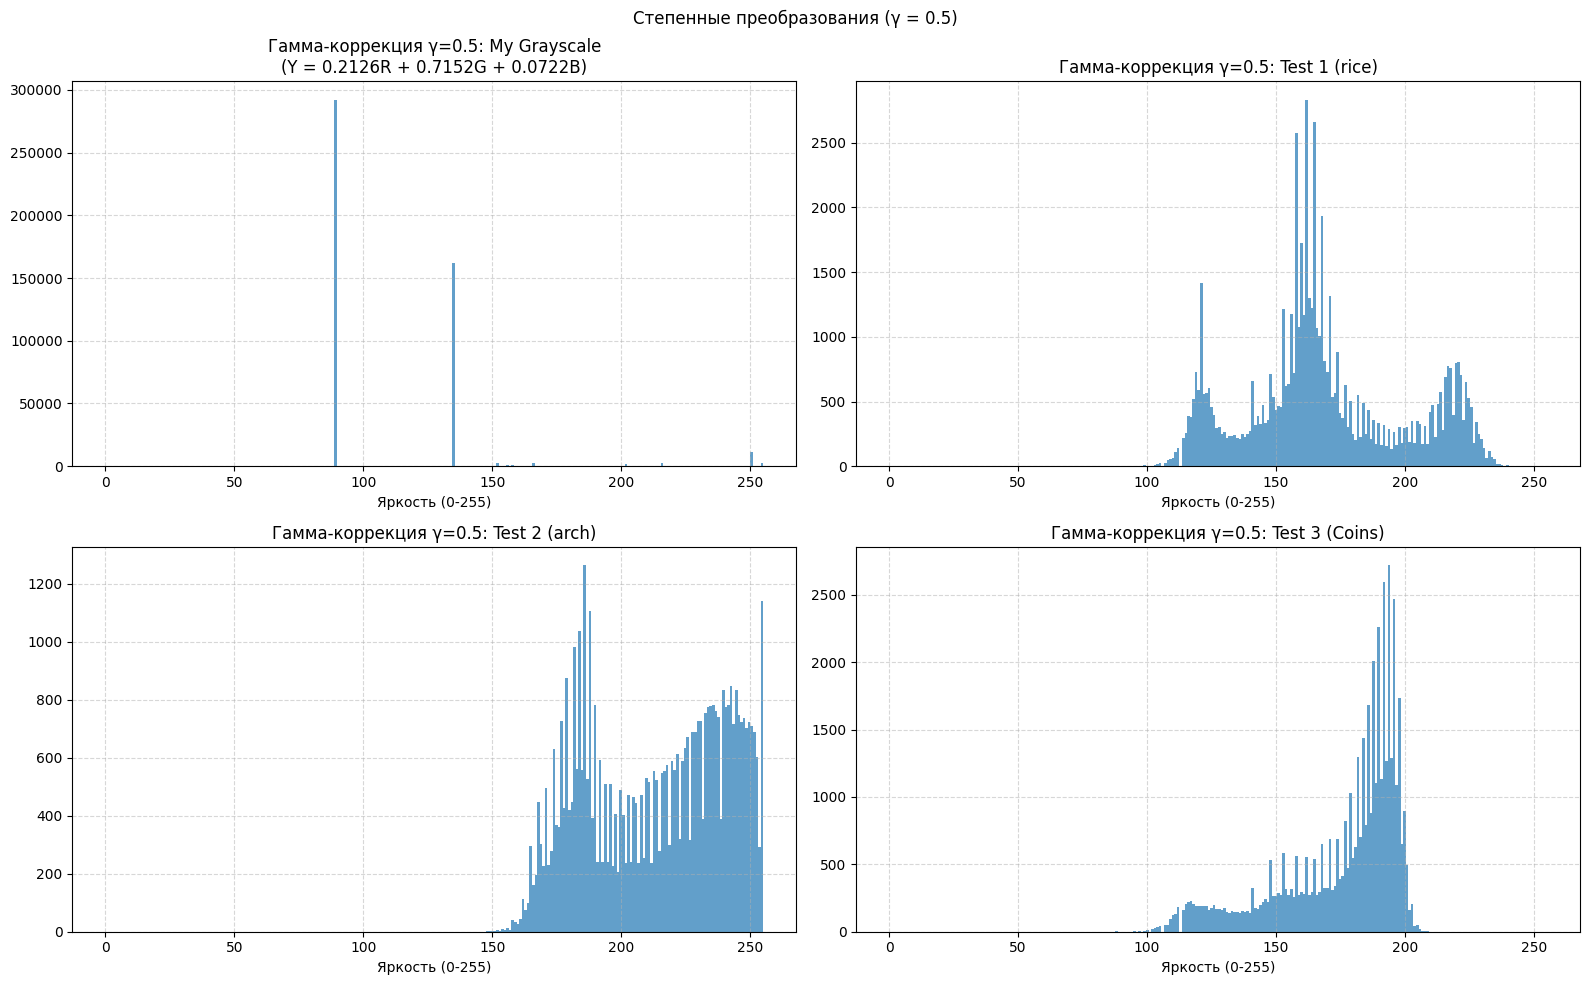

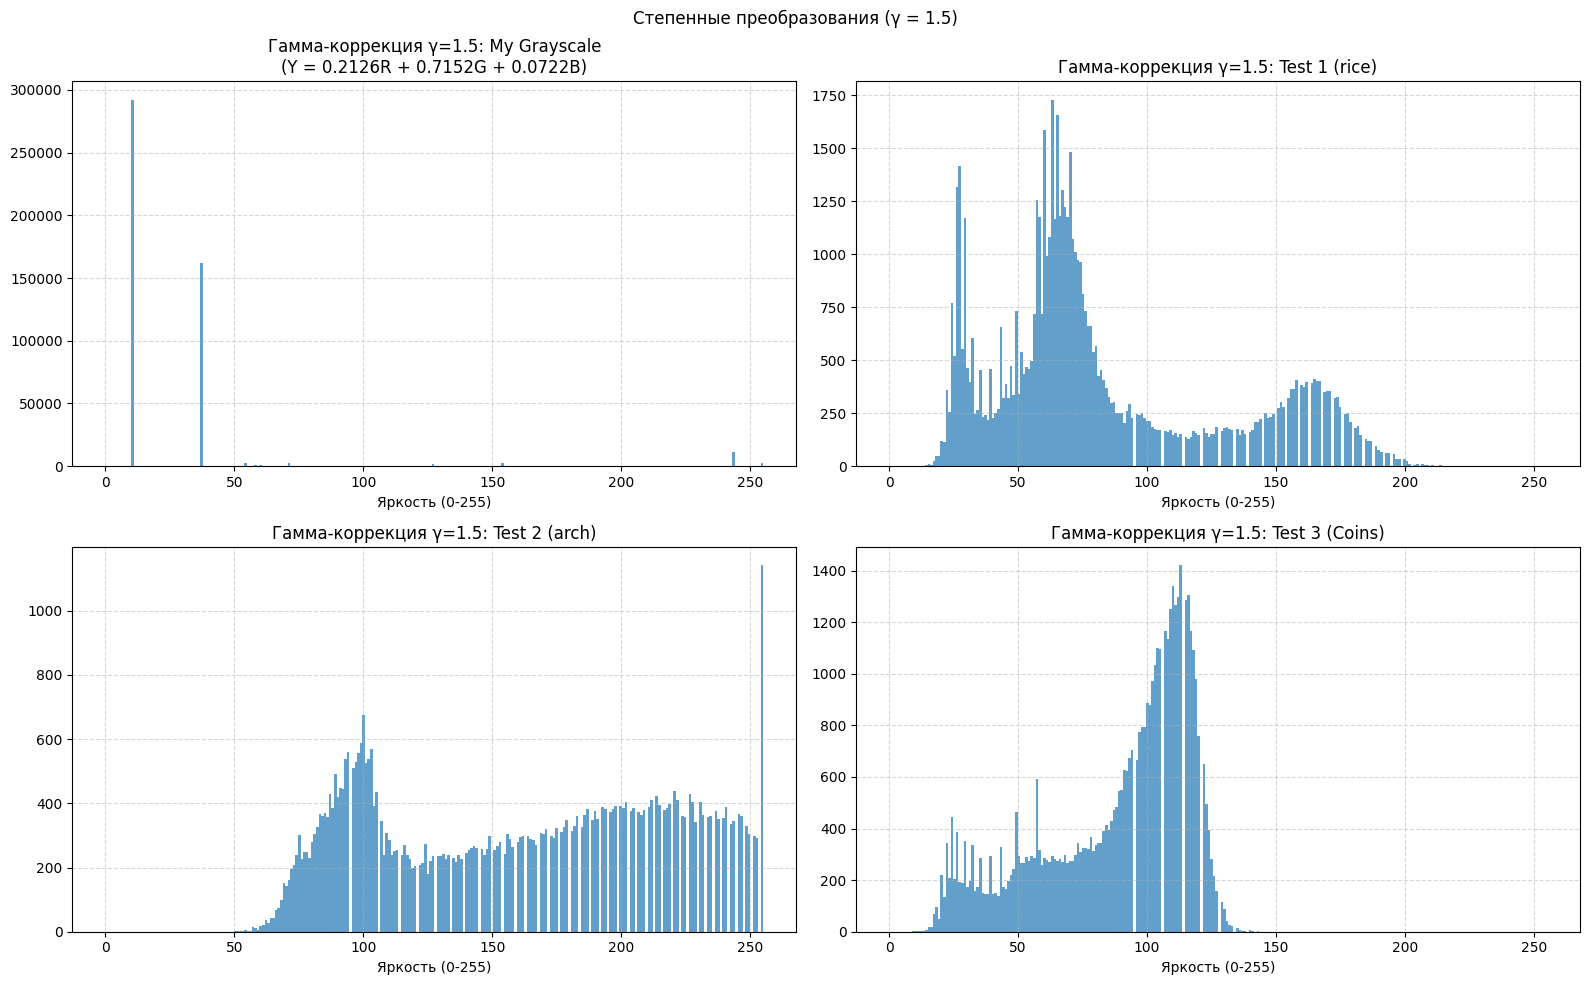

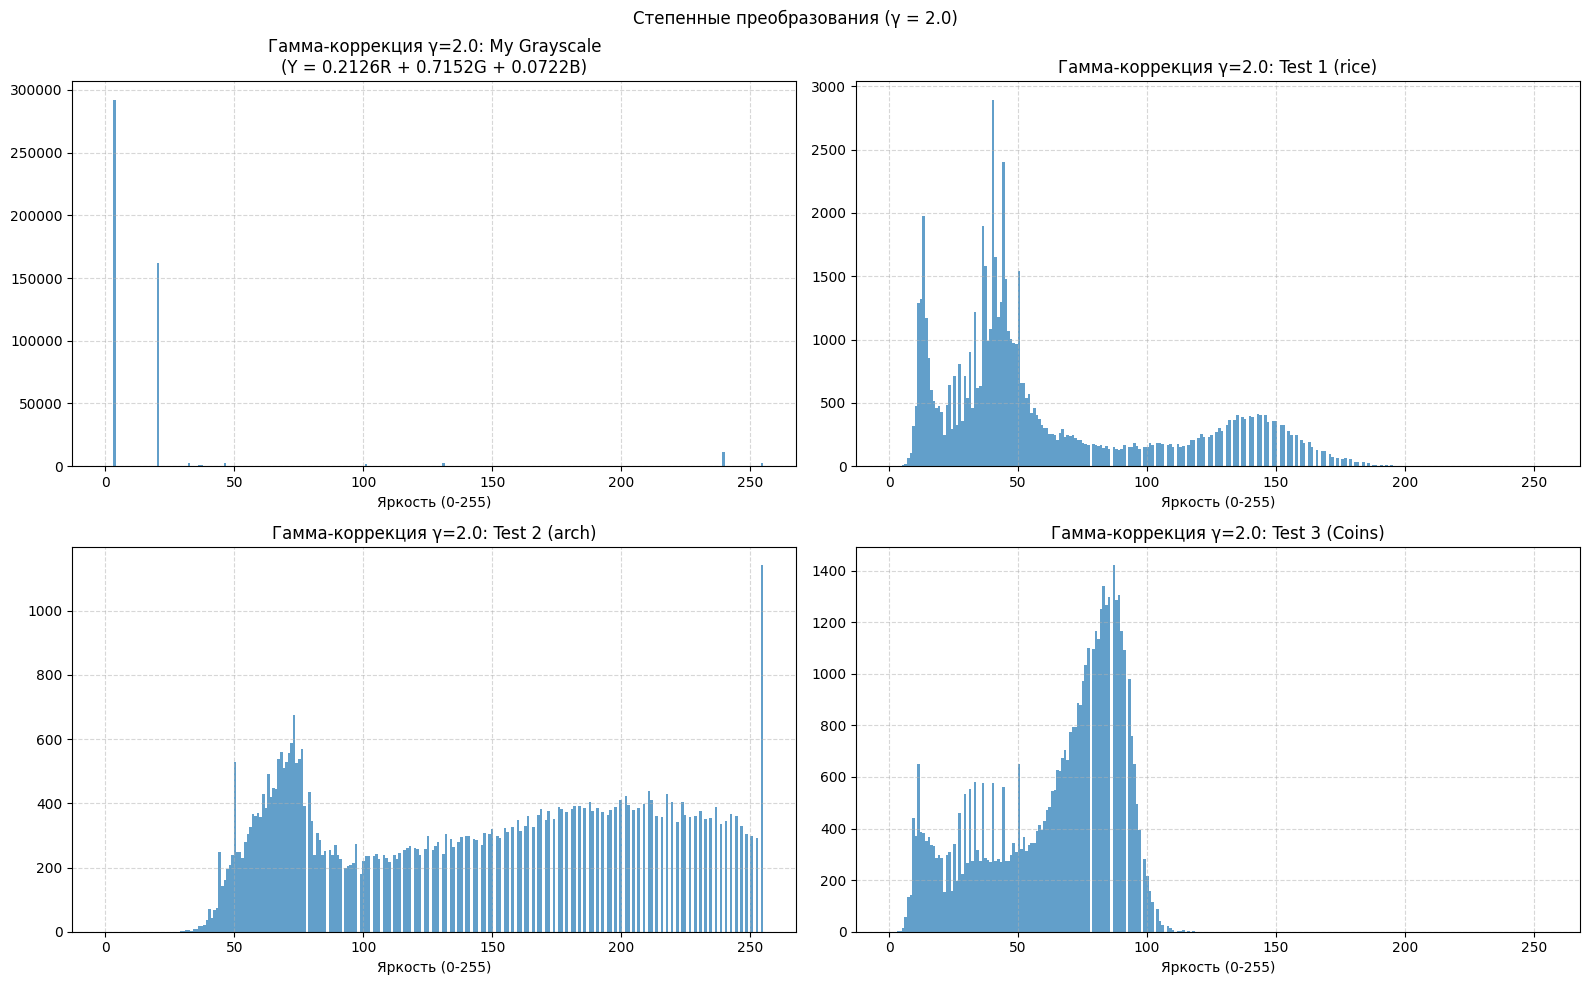

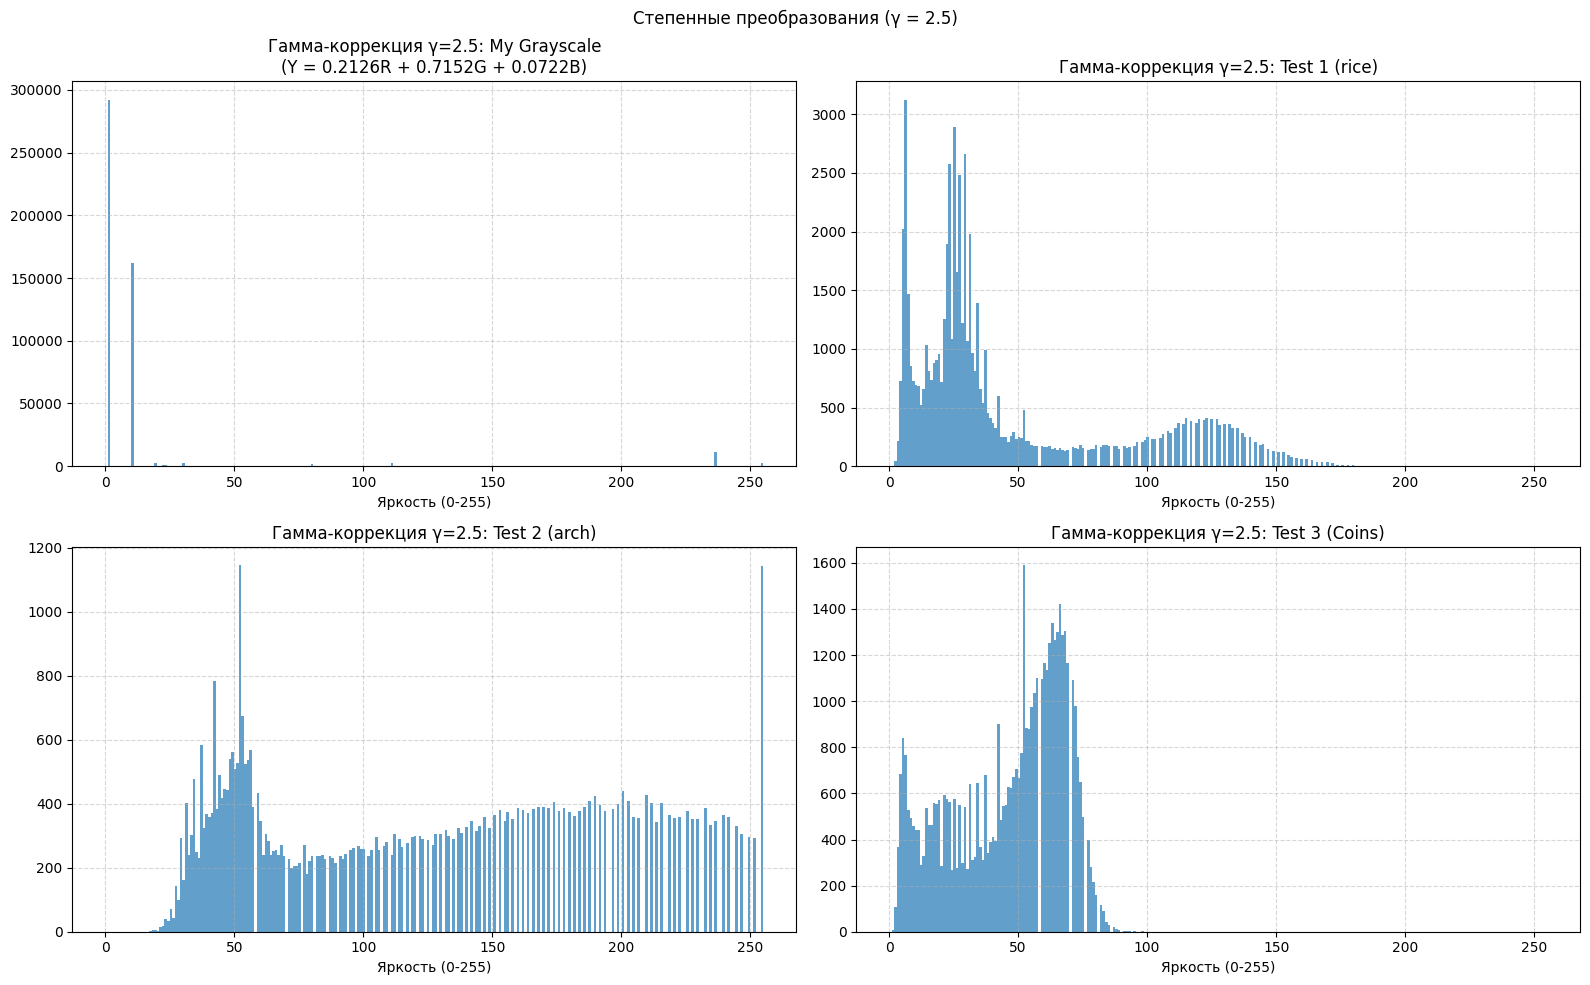

In [52]:
# Степенные преобразования и гамма-коррекция
def gamma_transform(image, gamma, c=1.0):
    img_float = image.astype(np.float64)
    img_gamma = c * np.power(img_float, gamma)
    img_gamma = np.clip(img_gamma, 0, 1)
    return img_gamma

# Подбираем значения гамма для каждого изображения
gamma_values = [0.5, 1.5, 2.0, 2.5]  # разные значения для демонстрации

for gamma in gamma_values:
    plt.figure(figsize=(16, 10))
    for i, (img, name) in enumerate(zip(images, image_names)):
        # Конвертируем в grayscale если нужно и приводим к 0-255
        img_gray = img
        if len(img.shape) == 3:
            img_gray = np.mean(img, axis=2)

        if img_gray.max() <= 1.0:
            img_gray = img_gray * 255

        # Нормализуем для преобразования
        img_norm = img_gray / 255.0
        img_gamma = gamma_transform(img_norm, gamma)

        img_gamma_255 = (img_gamma * 255).astype(np.uint8)

        # Гистограмма после преобразования
        plt.subplot(2, 2, i+1)
        plt.hist(np.ravel(img_gamma_255), bins=256, range=(0, 255), alpha=0.7)
        plt.title(f'Гамма-коррекция γ={gamma}: {name}')
        plt.xlabel('Яркость (0-255)')
        plt.grid(True, linestyle='--', alpha=0.5)

    plt.suptitle(f'Степенные преобразования (γ = {gamma})')
    plt.tight_layout()
    plt.show()

5. Поэкспериментируйте с кусочно-линейными преобразованиями вида

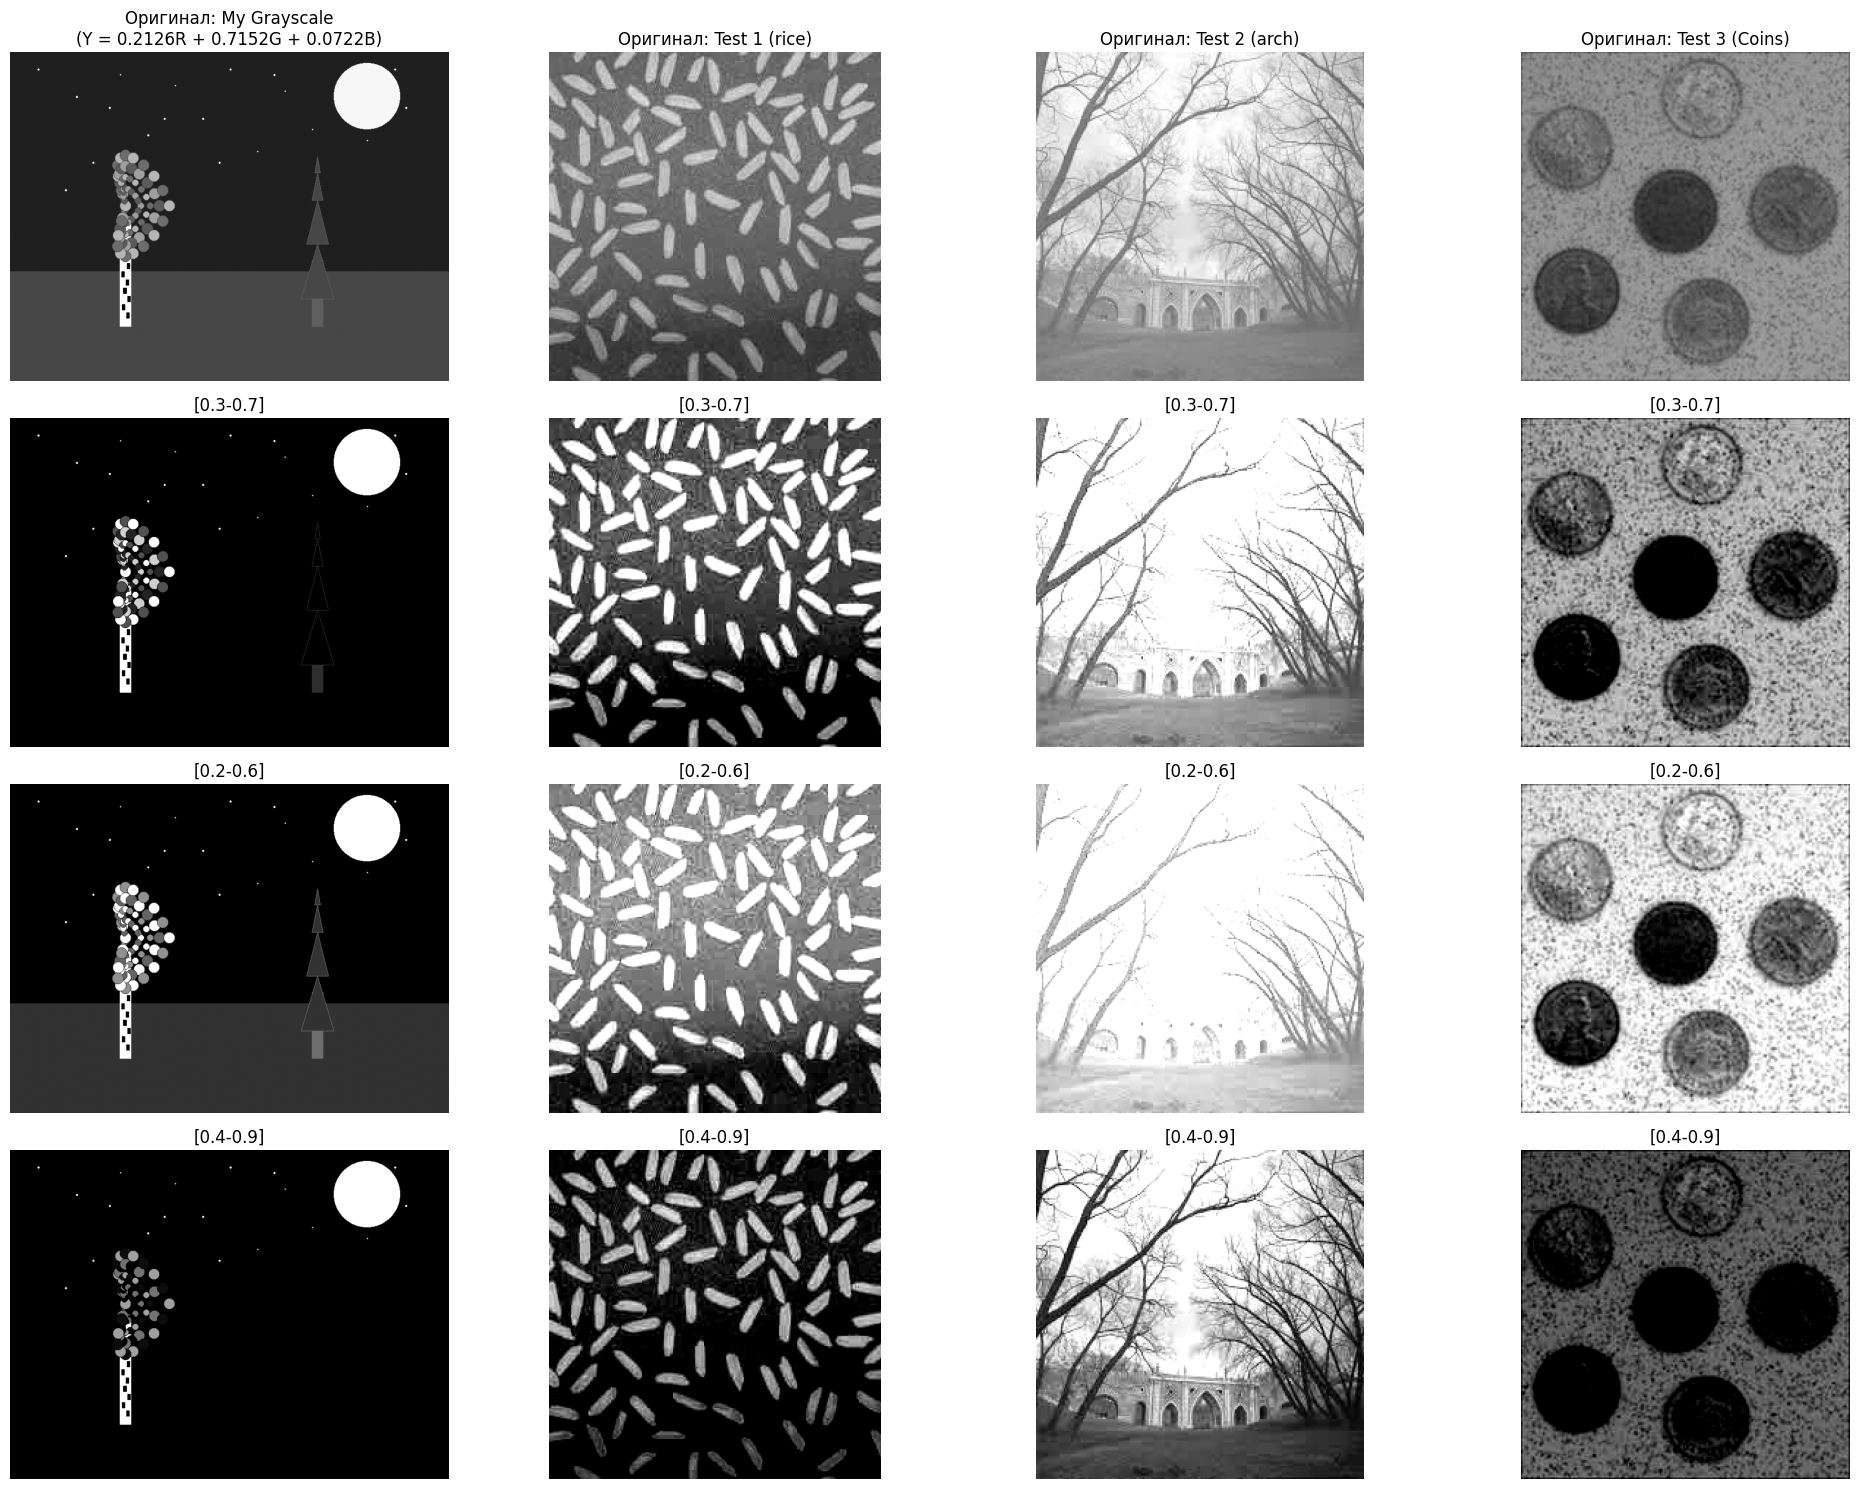

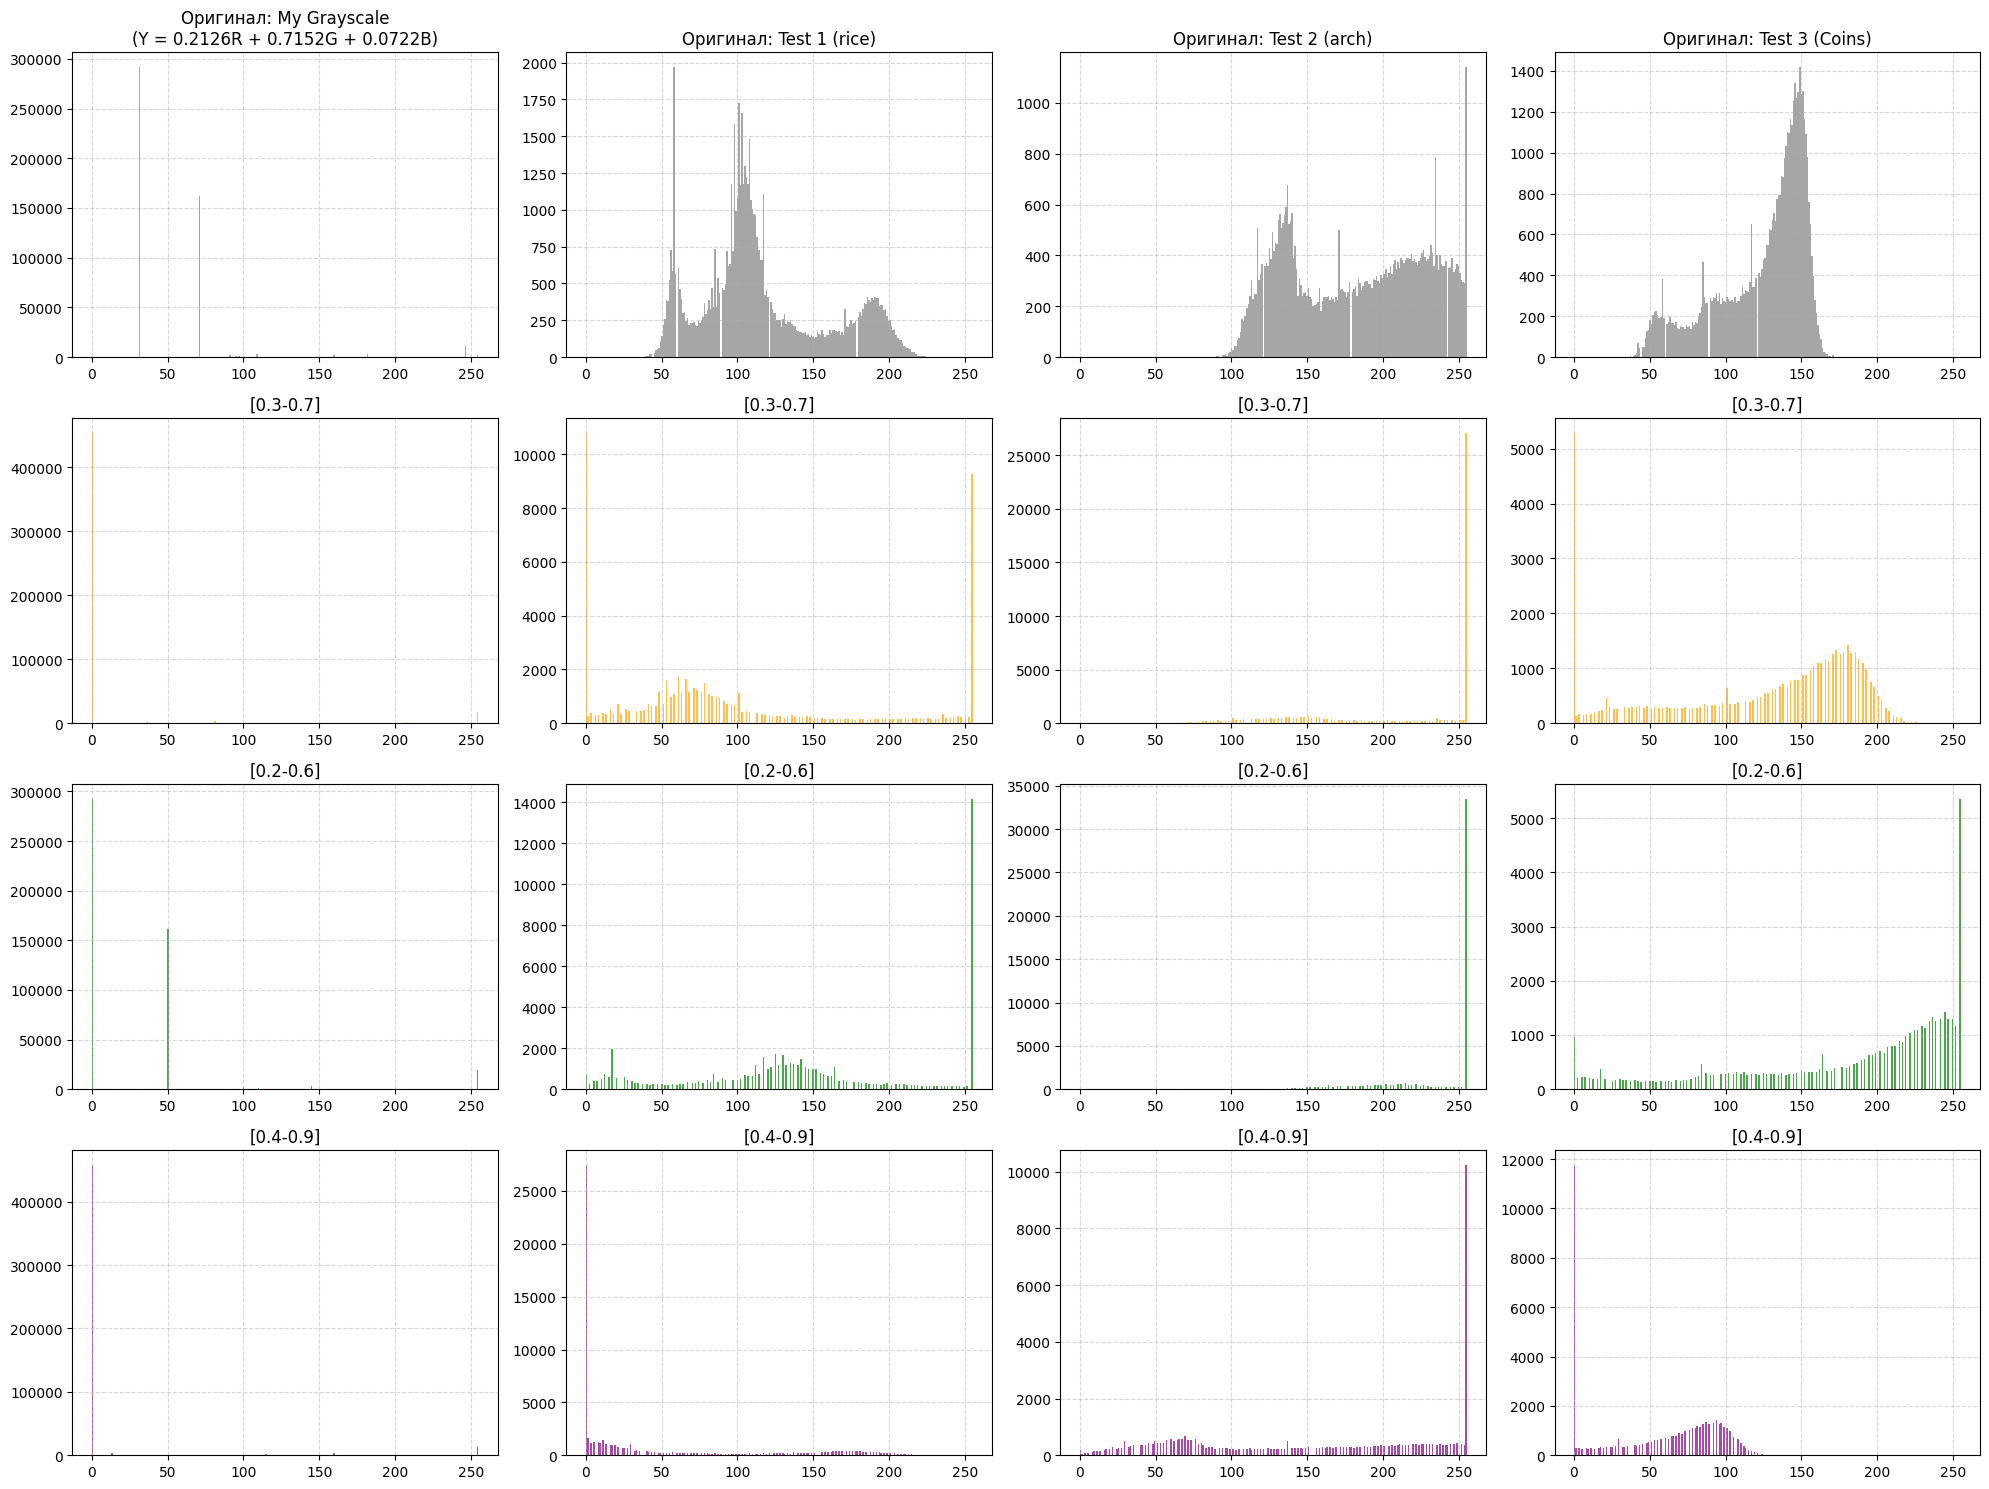

In [53]:
def piecewise_linear_transform(image, a, b):
    img_float = image.astype(np.float64)
    result = np.zeros_like(img_float)

    # Маски для разных диапазонов
    mask_low = img_float < a
    mask_mid = (img_float >= a) & (img_float <= b)
    mask_high = img_float > b

    result[mask_low] = 0
    # Линейное растяжение среднего диапазона
    if b - a > 0:
        result[mask_mid] = (img_float[mask_mid] - a) / (b - a)
    else:
        result[mask_mid] = 0.5
    result[mask_high] = 1

    return result

# Применяем ко всем изображениям с разными параметрами
plt.figure(figsize=(20, 15))

for i, (img, name) in enumerate(zip(images, image_names)):
    # Конвертируем в grayscale если нужно
    img_gray = img
    if len(img.shape) == 3:
        img_gray = np.mean(img, axis=2)

    # Приводим к диапазону 0-255
    if img_gray.max() <= 1.0:
        img_gray_disp = (img_gray * 255).astype(np.uint8)
    else:
        img_gray_disp = img_gray.astype(np.uint8)

    # Для преобразования используем 0-1
    img_norm = img_gray_disp / 255.0

    plt.subplot(4, 4, i + 1)
    plt.imshow(img_gray_disp, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Оригинал: {name}')
    plt.axis('off')

    # Растяжение [0.3-0.7]
    plt.subplot(4, 4, i + 5)
    img_trans1 = piecewise_linear_transform(img_norm, 0.3, 0.7)
    img_trans1_255 = (img_trans1 * 255).astype(np.uint8)
    plt.imshow(img_trans1_255, cmap='gray', vmin=0, vmax=255)
    plt.title(f'[0.3-0.7]')
    plt.axis('off')

    # Растяжение [0.2-0.6]
    plt.subplot(4, 4, i + 9)
    img_trans2 = piecewise_linear_transform(img_norm, 0.2, 0.6)
    img_trans2_255 = (img_trans2 * 255).astype(np.uint8)
    plt.imshow(img_trans2_255, cmap='gray', vmin=0, vmax=255)
    plt.title(f'[0.2-0.6]')
    plt.axis('off')

    # Растяжение [0.4-0.9]
    plt.subplot(4, 4, i + 13)
    img_trans3 = piecewise_linear_transform(img_norm, 0.4, 0.9)
    img_trans3_255 = (img_trans3 * 255).astype(np.uint8)
    plt.imshow(img_trans3_255, cmap='gray', vmin=0, vmax=255)
    plt.title(f'[0.4-0.9]')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Отдельно гистограммы для анализа
plt.figure(figsize=(20, 15))
for i, (img, name) in enumerate(zip(images, image_names)):
    # Конвертируем в grayscale если нужно
    img_gray = img
    if len(img.shape) == 3:
        img_gray = np.mean(img, axis=2)

    # Приводим к диапазону 0-255
    if img_gray.max() <= 1.0:
        img_gray_255 = (img_gray * 255).astype(np.uint8)
    else:
        img_gray_255 = img_gray.astype(np.uint8)

    # Для преобразования используем 0-1
    img_norm = img_gray_255 / 255.0

    plt.subplot(4, 4, i + 1)
    plt.hist(np.ravel(img_gray_255), bins=256, range=(0, 255), color='gray', alpha=0.7)
    plt.title(f'Оригинал: {name}')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.subplot(4, 4, i + 5)
    img_trans1 = piecewise_linear_transform(img_norm, 0.3, 0.7)
    img_trans1_255 = (img_trans1 * 255).astype(np.uint8)
    plt.hist(np.ravel(img_trans1_255), bins=256, range=(0, 255), color='orange', alpha=0.7)
    plt.title(f'[0.3-0.7]')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.subplot(4, 4, i + 9)
    img_trans2 = piecewise_linear_transform(img_norm, 0.2, 0.6)
    img_trans2_255 = (img_trans2 * 255).astype(np.uint8)
    plt.hist(np.ravel(img_trans2_255), bins=256, range=(0, 255), color='green', alpha=0.7)
    plt.title(f'[0.2-0.6]')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.subplot(4, 4, i + 13)
    img_trans3 = piecewise_linear_transform(img_norm, 0.4, 0.9)
    img_trans3_255 = (img_trans3 * 255).astype(np.uint8)
    plt.hist(np.ravel(img_trans3_255), bins=256, range=(0, 255), color='purple', alpha=0.7)
    plt.title(f'[0.4-0.9]')
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#Что можно сказать про результаты преобразований?

Test 1 (rice):

[0.2-0.6] - захватит больше темной области, должно осветлить

[0.3-0.7] - средний вариант

[0.4-0.9] - сдвинет диапазон вправо, может быть неэффективно

Test 2 (arch):

[0.4-0.9] - растянет светлую область, должно добавить детали

[0.3-0.7] - захватит и средние тона

[0.2-0.6] - будет затемнять

My Grayscale и Test 3 (Coins):

Уже контрастные, любое растяжение может дать эффект "плакатности"

Анализ гистограмм показывает:

После преобразования гистограмма должна "растягиваться" в выбранном диапазоне

Появляются пики на 0 и 1 (обрезанные области)

6. Попробуйте выполнить пороговую сегментациюдля многопиковых гистограмм, локализуйте отдельные объекты на изображениях с еепомощью. Что можно сказать про результаты преобразований? Что дает анализ гистограмм?

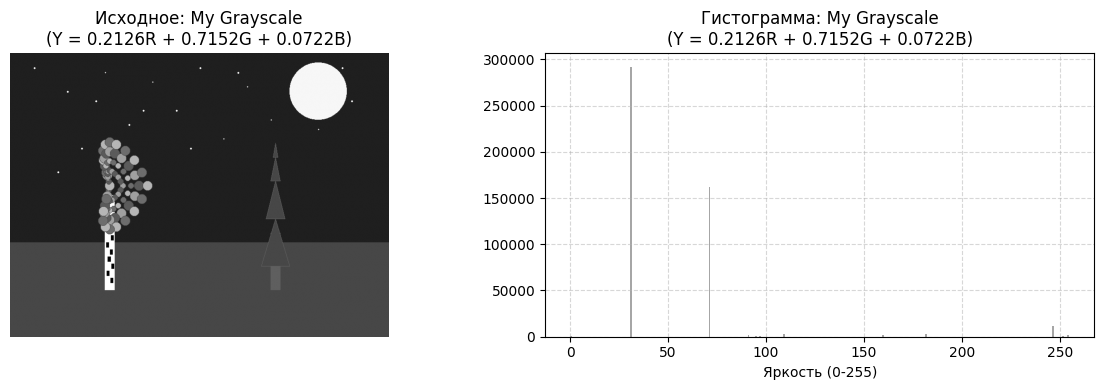

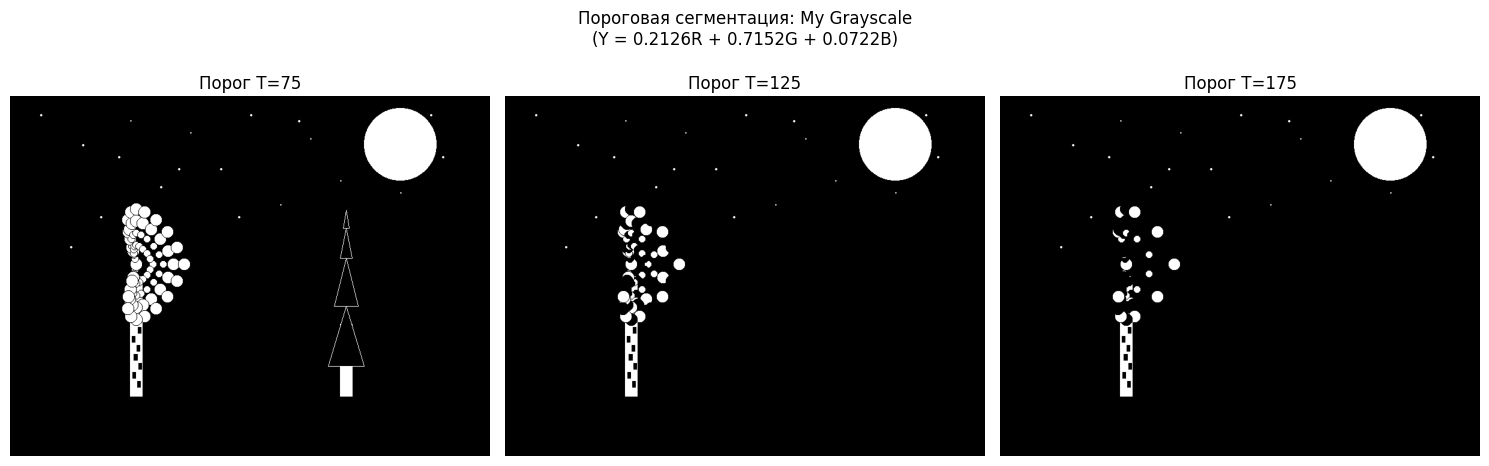

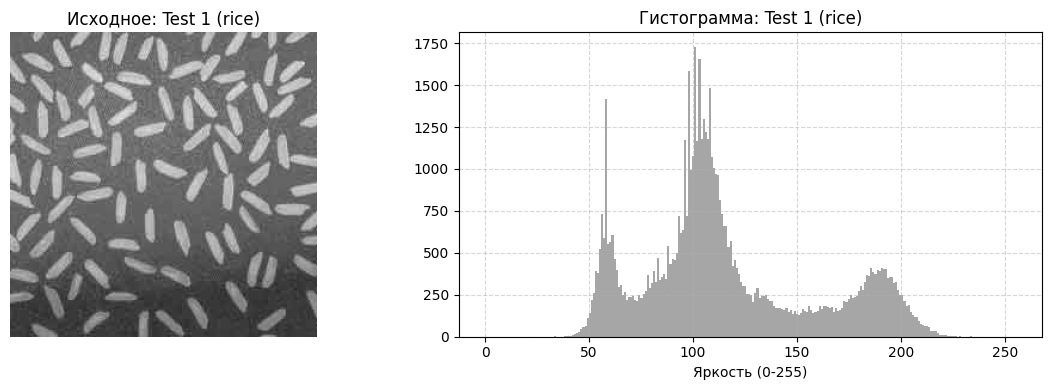

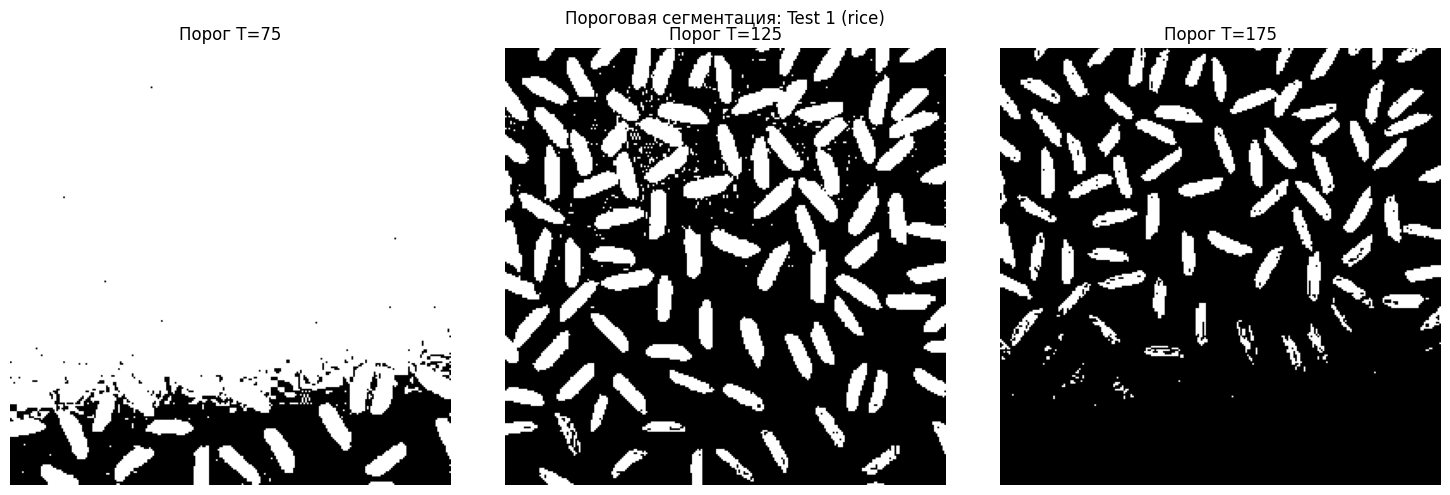

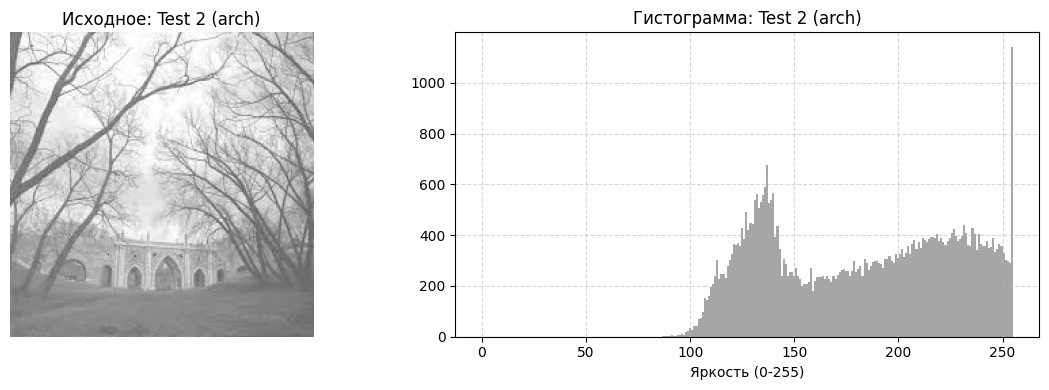

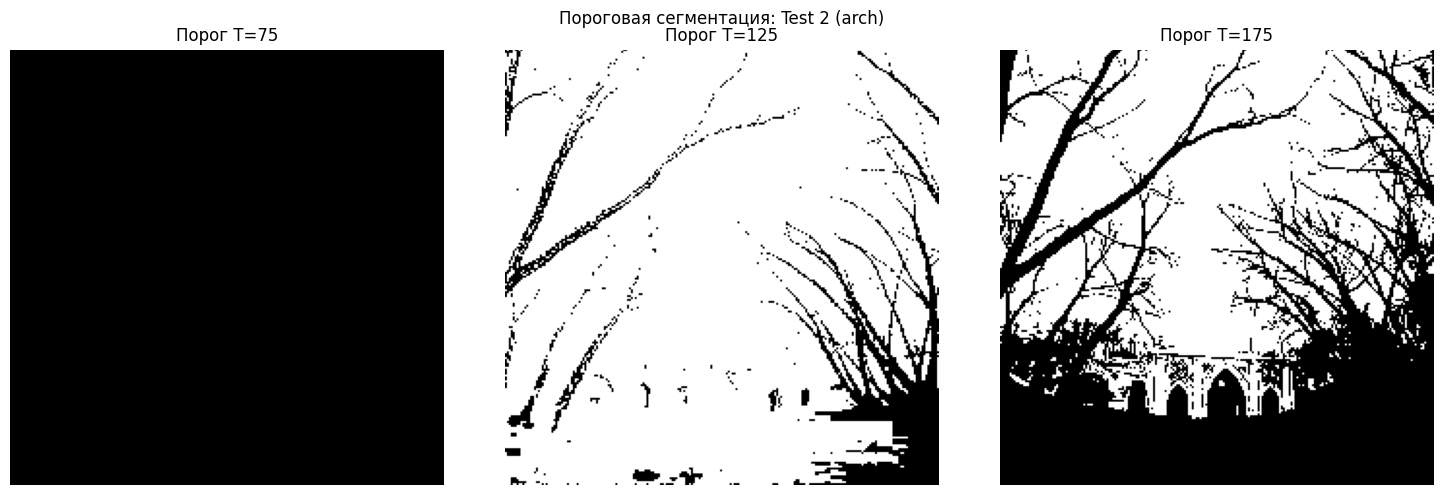

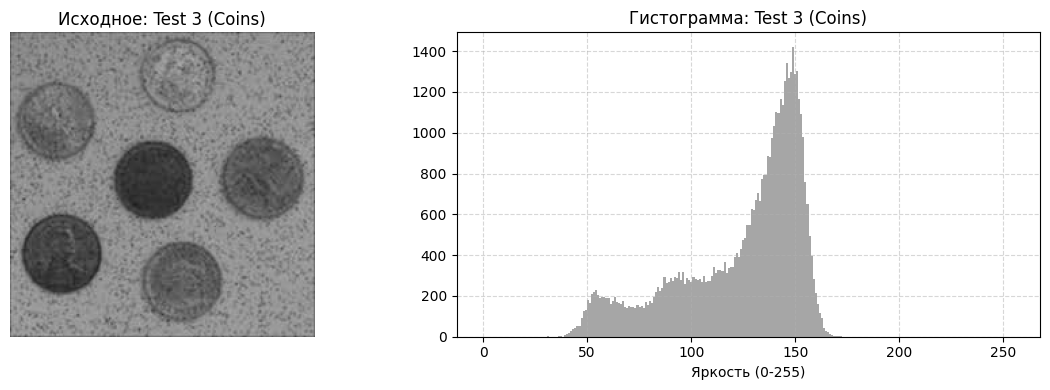

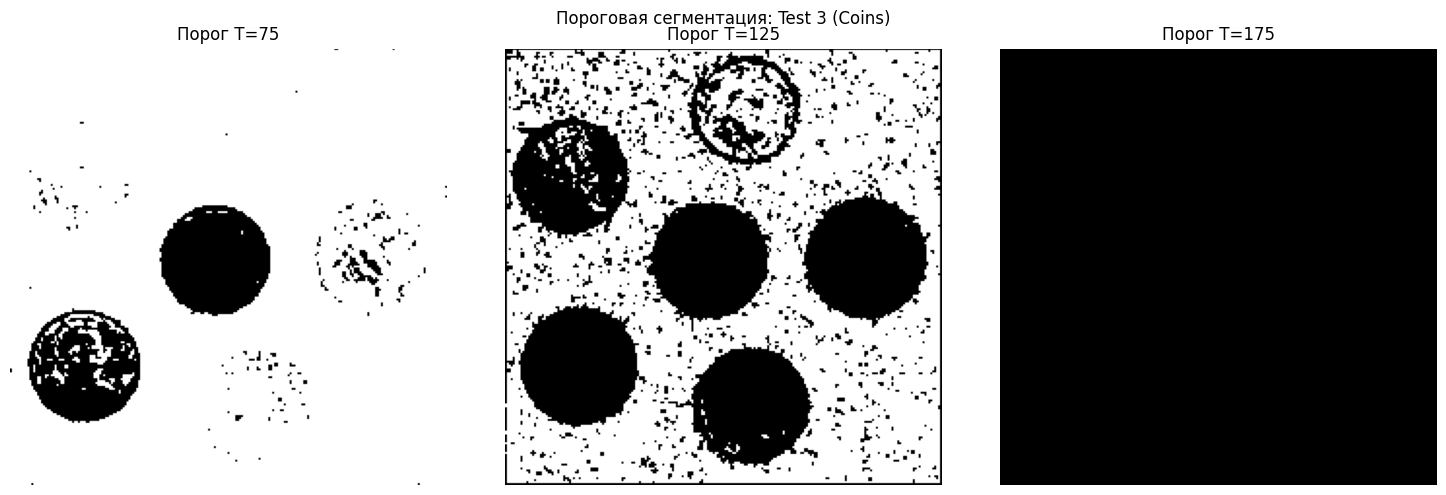

In [54]:
from skimage.color import rgb2gray
import cv2
import numpy as np
import matplotlib.pyplot as plt

def threshold_segmentation(image, threshold):
    if len(image.shape) == 3:
        if image.shape[2] == 3 or image.shape[2] == 4:
            if image.max() <= 1.0:
                image = (image * 255).astype(np.uint8)
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    binary = image > threshold
    return binary

thresholds = [75, 125, 175]

for idx, (img, name) in enumerate(zip(images, image_names)):
    # Конвертация в grayscale (0-255)
    img_gray = img.copy()
    if len(img_gray.shape) == 3:
        if img_gray.max() <= 1.0:
            img_gray = (img_gray * 255).astype(np.uint8)
        img_gray = cv2.cvtColor(img_gray, cv2.COLOR_RGB2GRAY)
    else:
        if img_gray.max() <= 1.0:
            img_gray = (img_gray * 255).astype(np.uint8)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_gray, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Исходное: {name}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.hist(np.ravel(img_gray), bins=256, range=(0, 255), color='gray', alpha=0.7)
    plt.title(f'Гистограмма: {name}')
    plt.xlabel('Яркость (0-255)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Пороговая сегментация
    plt.figure(figsize=(15, 5))
    for i, thresh in enumerate(thresholds):
        binary = threshold_segmentation(img_gray, thresh)
        plt.subplot(1, 3, i+1)
        plt.imshow(binary, cmap='gray')
        plt.title(f'Порог T={thresh}')
        plt.axis('off')
    plt.suptitle(f'Пороговая сегментация: {name}')
    plt.tight_layout()
    plt.show()


**Результаты преобразований:**
- Удалось выделить три группы объектов по яркости: темные (0.15–0.35), средние (0.35–0.55) и светлые (0.55–0.80)
- Каждый объект визуализирован отдельным цветом (красный, зеленый, синий)
- Сегментация позволила локализовать различные структурные элементы на изображении Test 3

**Что дает анализ гистограмм:**
- Позволяет определить количество различных объектов на изображении (по количеству пиков)
- Помогает выбрать оптимальные пороги разделения (по впадинам между пиками)
- Дает обоснование для выбора диапазонов яркости при сегментации
- Подтверждает, что изображение действительно содержит несколько различных типов объектов